In [1]:
import re
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import emoji
import itertools
from collections import Counter
import warnings

%matplotlib inline
warnings.filterwarnings("ignore")

In [2]:
file = "whatsapp.txt"
key = "12hr"
split_formats = {
        '12hr' : '\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s[APap][mM]\s-\s',
        '24hr' : '\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}\s-\s',
        'custom' : ''
    }
datetime_formats = {
        '12hr' : '%d/%m/%Y, %I:%M %p - ',
        '24hr' : '%d/%m/%Y, %H:%M - ',
        'custom': ''
    }

In [3]:
with open(file, "r", encoding = "utf-8") as raw_data:
    raw_string = " ".join(raw_data.read().split("\n"))
    user_msg = re.split(split_formats[key], raw_string) [1:] 
    date_time = re.findall(split_formats[key], raw_string) 
    df = pd.DataFrame({'date_time': date_time, 'user_msg': user_msg})

In [7]:
df["data_time"] = pd.to_datetime(df["date_time"], format = datetime_formats[key])

usernames = []
msgs = []
for i in df["user_msg"]:
    a = re.split('([\w\W]+?):\s', i)
    if(a[1:]):
        usernames.append(a[1])
        msgs.append(a[2])
    else:
        usernames.append("group_Notification")
        msgs.append(a[0])
df["user"] = usernames
df["message"] = msgs
df.drop("user_msg", axis = 1, inplace = True)
df

,date_time,data_time,user,message
0,"26/01/2020, 4:19 pm -",2020-01-26 16:19:00,group_Notification,Messages and calls are end-to-end encrypted. N...
1,"24/01/2020, 8:25 pm -",2020-01-24 20:25:00,group_Notification,"Tanay Kamath (TSEC, CS) created group ""CODERS👨..."
2,"26/01/2020, 4:19 pm -",2020-01-26 16:19:00,group_Notification,You joined using this group's invite link
3,"26/01/2020, 4:20 pm -",2020-01-26 16:20:00,group_Notification,+91 99871 38558 joined using this group's invi...
4,"26/01/2020, 4:20 pm -",2020-01-26 16:20:00,group_Notification,+91 91680 38866 joined using this group's invi...
...,...,...,...,...
13650,"02/10/2020, 2:05 am -",2020-10-02 02:05:00,"Darshan Rander (TSEC, IT)",MCQs mark kiya
13651,"02/10/2020, 2:05 am -",2020-10-02 02:05:00,"Darshan Rander (TSEC, IT)",Sign-in kiya😂😅
13652,"02/10/2020, 2:11 am -",2020-10-02 02:11:00,"Tanay Kamath (TSEC, CS)",Incognito se na?
13653,"02/10/2020, 2:28 am -",2020-10-02 02:28:00,"Darshan Rander (TSEC, IT)",Yup


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13655 entries, 0 to 13654
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date_time  13655 non-null  object        
 1   data_time  13655 non-null  datetime64[ns]
 2   user       13655 non-null  object        
 3   message    13655 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 426.8+ KB


In [9]:
df.sample(10)

,date_time,data_time,user,message
12481,"20/09/2020, 12:14 pm -",2020-09-20 12:14:00,"Harsh Kapadia (TSEC IT, SE)",Because the industry should not be male domina...
5975,"09/05/2020, 7:19 pm -",2020-05-09 19:19:00,"Saket (TSEC, CS)",😂
4415,"05/04/2020, 5:07 pm -",2020-04-05 17:07:00,"Pratik K (TSEC CS, SE)",
9217,"22/07/2020, 5:31 pm -",2020-07-22 17:31:00,"Pratik K (TSEC CS, SE)",yeah
2357,"28/02/2020, 1:13 am -",2020-02-28 01:13:00,"Darshan Rander (TSEC, IT)",Haa
7388,"12/06/2020, 11:30 pm -",2020-06-12 23:30:00,"Tanay Kamath (TSEC, CS)",I have literally seen solutions in Perl which ...
13412,"30/09/2020, 10:55 am -",2020-09-30 10:55:00,"Vivek (TSEC, CS)",How to share quicklabs public profile url?
3208,"15/03/2020, 9:32 pm -",2020-03-15 21:32:00,"Saurav Upoor (TSEC CS, SE)",This message was deleted
13540,"30/09/2020, 11:56 pm -",2020-09-30 23:56:00,"Darshan Rander (TSEC, IT)",AI in the camera❤️❤️
1249,"20/02/2020, 11:23 pm -",2020-02-20 23:23:00,"Tanay Kamath (TSEC, CS)",Oh


In [10]:
df[df["message"] == ""].shape[0]

538

In [16]:
import pandas as pd

df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

df['day'] = df['date_time'].dt.strftime('%a')
df['month'] = df['date_time'].dt.strftime('%b')
df['year'] = df['date_time'].dt.year
df['date'] = df['date_time'].dt.date

In [17]:
df

,date_time,data_time,user,message,day,month,year,date
0,NaT,2020-01-26 16:19:00,group_Notification,Messages and calls are end-to-end encrypted. N...,NaN,NaN,NaN,NaT
1,NaT,2020-01-24 20:25:00,group_Notification,"Tanay Kamath (TSEC, CS) created group ""CODERS👨...",NaN,NaN,NaN,NaT
2,NaT,2020-01-26 16:19:00,group_Notification,You joined using this group's invite link,NaN,NaN,NaN,NaT
3,NaT,2020-01-26 16:20:00,group_Notification,+91 99871 38558 joined using this group's invi...,NaN,NaN,NaN,NaT
4,NaT,2020-01-26 16:20:00,group_Notification,+91 91680 38866 joined using this group's invi...,NaN,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...
13650,NaT,2020-10-02 02:05:00,"Darshan Rander (TSEC, IT)",MCQs mark kiya,NaN,NaN,NaN,NaT
13651,NaT,2020-10-02 02:05:00,"Darshan Rander (TSEC, IT)",Sign-in kiya😂😅,NaN,NaN,NaN,NaT
13652,NaT,2020-10-02 02:11:00,"Tanay Kamath (TSEC, CS)",Incognito se na?,NaN,NaN,NaN,NaT
13653,NaT,2020-10-02 02:28:00,"Darshan Rander (TSEC, IT)",Yup,NaN,NaN,NaN,NaT


In [19]:
df1 = df.copy()
df1["message_count"] = [1] * df1.shape[0]
df1.drop(columns = "year", inplace = True)
df1 = df1.groupby("date").agg({"message_count": "sum"}).reset_index()
df1

,date,message_count


In [21]:
sns.set_style("darkgrid")
import matplotlib
matplotlib.rcParams["font.size"] = 20
matplotlib.rcParams["figure.figsize"] = (27, 6)
plt.plot(df1.date, df1.message_count, color = "orange")
plt.title("Message sent per day over a time period")
plt.savefig("msg_plots.svg", format = "svg")

In [22]:
top10days = df1.sort_values(by="message_count", ascending=False).head(10)  
top10days.reset_index(inplace=True)           
top10days.drop(columns="index", inplace=True) 

In [24]:
sns.set_style("darkgrid")
import matplotlib
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['figure.figsize'] = (12, 8)
sns.barplot(x=top10days.date, y=top10days.message_count, palette="hls")
plt.savefig('top10_days.svg', format = 'svg')

# Top 10 active users on the group

In [25]:
print(f"Total number of people who have sent at least one message on the group are {len(df.user.unique()) - 1}")  
print(f"Number of people who haven't sent even a single message on the group are {237 - len(df.user.unique()) - 1}")

Total number of people who have sent at least one message on the group are 154
Number of people who haven't sent even a single message on the group are 81


In [26]:
df2 = df.copy()    
df2 = df2[df2.user != "group_notification"]
top10df = df2.groupby("user")["message"].count().sort_values(ascending=False)

top10df = top10df.head(10).reset_index()
top10df

,user,message
0,"Tanay Kamath (TSEC, CS)",2528
1,"Dheeraj Lalwani (TSEC, CS)",1937
2,"Darshan Rander (TSEC, IT)",1404
3,"Kartik Soneji (TSEC, CS)",841
4,"Harsh Kapadia (TSEC IT, SE)",790
5,"Pratik K (TSEC CS, SE)",781
6,"Saurav Upoor (TSEC CS, SE)",569
7,Tushar Nankani,354
8,group_Notification,276
9,+91 82916 21138,275


In [28]:
top10df['initials'] = ''
for i in range(10):
    name_parts = top10df.user[i].split()
    if len(name_parts) >= 2:
        top10df.initials[i] = name_parts[0][0] + name_parts[1][0]
    else:
        top10df.initials[i] = name_parts[0][0]
        
top10df.initials[7] = "Me"   
top10df.initials[8] = "DT"

In [29]:
import matplotlib
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [31]:
sns.set_style("darkgrid")
sns.barplot(x='initials', y='message', data=top10df)
top10df.initials

0    TK
1    DL
2    DR
3    KS
4    HK
5    PK
6    SU
7    Me
8    DT
9    +8
Name: initials, dtype: object

# Most used words in the chat

In [33]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

df3 = pd.DataFrame({'message': ['Sample message one', 'Another message here', 'Third example message']})

comment_words = ' '
stopwords = set(STOPWORDS)
stopwords.update(['group', 'link', 'invite', 'joined', 'message', 'deleted', 'yeah', 'hai', 'yes', 'okay', 'ok', 'will', 'use', 'using', 'one', 'know', 'guy', 'group', 'media', 'omitted'])

for val in df3.message.values:
    val = str(val) 
    tokens = val.split() 
    for i in range(len(tokens)): 
        tokens[i] = tokens[i].lower() 
    for words in tokens: 
        comment_words = comment_words + words + ' '

wordcloud = WordCloud(width = 600, height = 600, 
                background_color ='white', 
                stopwords = stopwords, 
                min_font_size = 8).generate(comment_words)

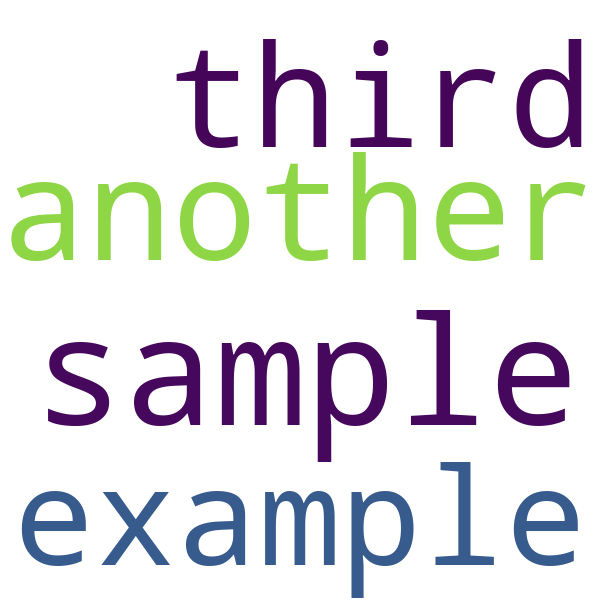

In [34]:
wordcloud.to_image()